# Feature-Based Machine Learning Forecasting Using XGBoost

## Part 6 – Appliance Energy Prediction Using Machine Learning

This notebook develops a feature-based machine learning forecasting model for appliance energy consumption.

Unlike statistical time-series models such as SARIMA and SARIMAX, machine learning models learn complex nonlinear relationships between energy usage and explanatory variables.

The XGBoost regression algorithm is selected because it performs effectively on structured datasets and can incorporate multiple feature types, including:

- Time-based variables
- Indoor sensor measurements
- Outdoor weather conditions
- Historical appliance consumption patterns

The model performance is evaluated using the same 24-hour forecasting horizon and metrics used in previous experiments.

The objective is to determine whether a feature-based machine learning approach improves forecasting accuracy compared with traditional statistical models.

# 2. Import Required Libraries

The required libraries for machine learning modelling, evaluation and visualisation are imported.

The workflow follows a supervised learning approach where historical observations are transformed into input features and the appliance energy consumption value is used as the prediction target.

In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   -- ------------------------------------- 3.4/48.9 MB 17.5 MB/s eta 0:00:03
   ----- ---------------------------------- 7.3/48.9 MB 17.7 MB/s eta 0:00:03
   -------- ------------------------------- 10.7/48.9 MB 17.0 MB/s eta 0:00:03
   ----------- ---------------------------- 14.4/48.9 MB 16.9 MB/s eta 0:00:03
   -------------- ------------------------- 18.1/48.9 MB 16.9 MB/s eta 0:00:02
   ----------------- ---------------------- 22.0/48.9 MB 17.1 MB/s eta 0:00:02
   -------------------- ------------------- 25.7/48.9 MB 17.3 MB/s eta 0:00:02
   ----------------------- ---------------- 28.8/48.9 MB 17.0 MB/s eta 0:00:02
   -------------------------- ------------- 32.8/48.9 MB 17.0 MB/s eta 0:00:01
   ----------------------------- ---------- 35.9/48.9 MB 16.9 MB/s eta 0:00:01
   ------------------------------- -------- 38.8/48.9 MB 16.7 MB/s eta 0:00:01
   ---------------------------------- ----- 42.2/48.9 MB 16.5 M


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 3. Loading the Feature-Engineered Dataset

The feature-engineered dataset created during the SARIMAX modelling stage is loaded.

This dataset contains:

- Appliance energy consumption (target variable)
- Time-based features
- Indoor sensor features
- Outdoor weather variables
- Lag features
- Rolling statistics

Using the saved dataset ensures that the machine learning workflow is reproducible and independent from previous notebooks.

In [6]:
import pandas as pd


ml_df = pd.read_csv(
    "../data/ml_features_energy.csv",
    index_col="date",
    parse_dates=True
)


ml_df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,indoor_temp_mean,indoor_temp_std,indoor_humidity_mean,indoor_humidity_std,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168
date,,,,,,,,,,,,,,,,,,,,,
2016-01-18 17:00:00,35.000000,0.000000,19.172222,41.175556,17.962222,41.530000,19.500000,40.693889,18.616667,38.084722,...,16.274994,6.701994,50.386125,20.102894,46.666667,455.000000,55.000000,61.805556,50.702592,113.779762
2016-01-18 18:00:00,300.000000,8.333333,19.100000,41.075556,17.812222,41.527778,19.357222,40.324444,18.457222,38.157222,...,16.113525,6.902517,50.520151,20.400950,35.000000,268.333333,176.666667,63.125000,56.402437,114.513889
2016-01-18 19:00:00,195.000000,8.333333,19.574444,42.057778,18.263750,42.203889,19.488889,40.265556,18.317778,38.393333,...,16.191889,7.169740,50.734191,19.437200,300.000000,101.666667,173.333333,67.013889,62.104749,114.642857
2016-01-18 20:00:00,558.333333,10.000000,20.258611,41.407083,19.100556,42.037778,20.196667,43.094444,18.611667,38.590972,...,16.582998,7.448866,53.217023,21.354396,195.000000,110.000000,125.000000,85.694444,117.931976,117.222222
2016-01-18 21:00:00,345.000000,11.666667,20.642222,40.164444,19.583788,40.143586,21.028889,45.406667,21.140000,37.362222,...,16.901462,7.881647,52.786853,22.191014,558.333333,130.000000,103.333333,94.652778,129.082585,118.660714


In [7]:
ml_df.shape

(3122, 45)

# 4. Feature and Target Definition

A supervised machine learning problem is created where previous observations and environmental conditions are used to predict future appliance energy consumption.

The target variable is appliance energy usage.

All predictor variables represent information available before the forecast time.

In [8]:
# Remove target from features

X = ml_df.drop(
    columns=["Appliances"]
)


y = ml_df["Appliances"]


print(X.shape)

print(y.shape)

(3122, 44)
(3122,)


# 5. Train-Test Split

A chronological split is applied to simulate a real forecasting scenario.

The final 14 days of observations are reserved as unseen test data.

Random splitting is avoided because it would introduce future information into the training data and create unrealistic performance estimates.

In [9]:
test_size = 14 * 24


X_train = X.iloc[:-test_size]

X_test = X.iloc[-test_size:]


y_train = y.iloc[:-test_size]

y_test = y.iloc[-test_size:]


print("Training:", X_train.shape)

print("Testing:", X_test.shape)

Training: (2786, 44)
Testing: (336, 44)


# 6. Training the XGBoost Regression Model

The XGBoost model is trained using historical appliance consumption features and environmental variables.

The model learns nonlinear relationships between input variables and future appliance demand.

The model parameters are selected using reasonable default values to provide a strong baseline while avoiding excessive tuning complexity.

In [10]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


xgb_model.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


# 7. Generating a 24-Hour Appliance Energy Forecast

The trained XGBoost regression model is used to predict appliance energy consumption for the next 24 hours.

The final 14 days were reserved as unseen test data. For consistency with previous SARIMA and SARIMAX models, the evaluation focuses on the first 24 hours of the test period.

The model predictions are generated using only the feature values available in the test dataset.

In [11]:
# Generate predictions for first 24 hours

xgb_prediction = xgb_model.predict(
    X_test.iloc[:24]
)


actual_xgb = y_test.iloc[:24]


xgb_prediction[:5]

array([220.9472  , 241.75574 , 119.233574,  90.99695 ,  83.564156],
      dtype=float32)

# 8. Visualising XGBoost Forecast Results

The predicted appliance energy consumption values are compared against the actual recorded energy usage.

This visual comparison helps evaluate whether the machine learning model captures short-term changes and daily consumption patterns.

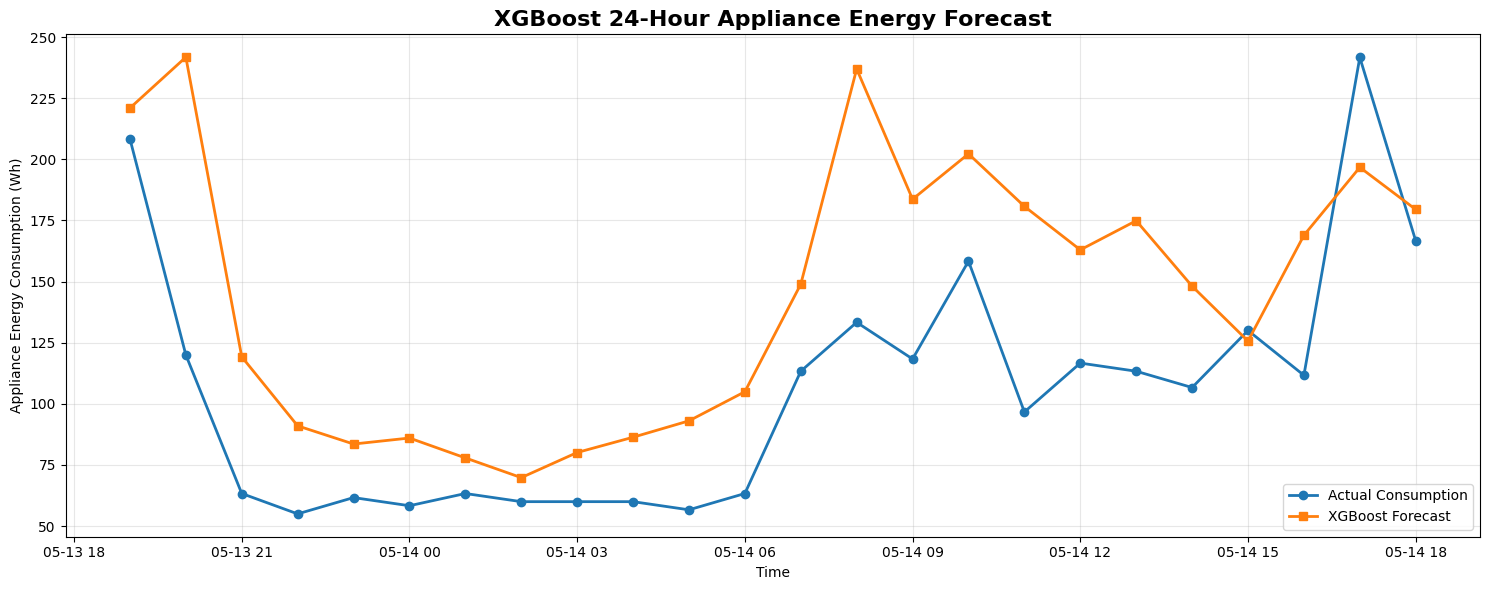

In [12]:
plt.figure(figsize=(15,6))


plt.plot(
    actual_xgb.index,
    actual_xgb,
    marker="o",
    linewidth=2,
    label="Actual Consumption"
)


plt.plot(
    actual_xgb.index,
    xgb_prediction,
    marker="s",
    linewidth=2,
    label="XGBoost Forecast"
)


plt.title(
    "XGBoost 24-Hour Appliance Energy Forecast",
    fontsize=16,
    fontweight="bold"
)


plt.xlabel("Time")

plt.ylabel(
    "Appliance Energy Consumption (Wh)"
)


plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()


plt.savefig(
    "../outputs/figures/xgboost_24hour_forecast.png",
    dpi=300
)


plt.show()

# 9. XGBoost Forecast Evaluation

The performance of the XGBoost model is evaluated using the same metrics used for the statistical forecasting models.

The following metrics are calculated:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)
- R² score

Using identical evaluation metrics allows a fair comparison between SARIMA, SARIMAX and machine learning approaches.

In [13]:
mae_xgb = mean_absolute_error(
    actual_xgb,
    xgb_prediction
)


rmse_xgb = np.sqrt(
    mean_squared_error(
        actual_xgb,
        xgb_prediction
    )
)


mape_xgb = np.mean(
    np.abs(
        (actual_xgb.values - xgb_prediction)
        /
        actual_xgb.values
    )
) * 100


r2_xgb = r2_score(
    actual_xgb,
    xgb_prediction
)


print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"MAPE : {mape_xgb:.2f}%")
print(f"R²   : {r2_xgb:.3f}")

MAE  : 42.74
RMSE : 51.44
MAPE : 45.15%
R²   : -0.088


# 10. XGBoost Feature Importance Analysis

Unlike statistical models, tree-based machine learning models provide feature importance scores.

These values indicate which variables contributed most to prediction decisions.

Feature importance helps interpret whether appliance consumption is mainly influenced by:

- Previous energy consumption patterns
- Weather conditions
- Indoor environment
- Time-based behaviour patterns

This analysis improves model explainability and supports discussion of important predictors in the final report.

In [14]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": xgb_model.feature_importances_

})


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


importance.head(15)

,Feature,Importance
38,lag_1,0.130957
27,hour,0.081290
42,rolling_std_24,0.063175
31,working_hours,0.056367
32,hour_sin,0.052742
33,hour_cos,0.031410
28,day_of_week,0.029337
41,rolling_mean_24,0.026871
40,lag_168,0.023212
39,lag_24,0.022670


<Figure size 1000x700 with 0 Axes>

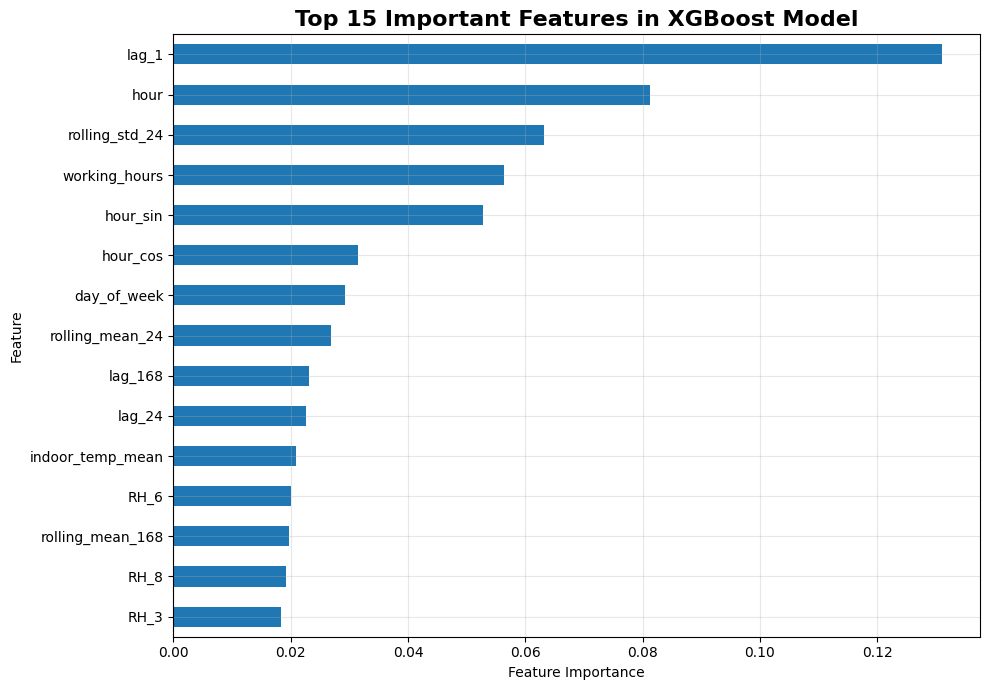

In [15]:
plt.figure(figsize=(10,7))


importance.head(15).sort_values(
    "Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10,7),
    legend=False
)


plt.title(
    "Top 15 Important Features in XGBoost Model",
    fontsize=16,
    fontweight="bold"
)


plt.xlabel(
    "Feature Importance"
)


plt.ylabel(
    "Feature"
)


plt.grid(alpha=0.3)

plt.tight_layout()


plt.savefig(
    "../outputs/figures/xgboost_feature_importance.png",
    dpi=300
)


plt.show()

# 11. Model Performance Comparison

The XGBoost model is compared against previous forecasting approaches:

- SARIMA baseline
- SARIMAX with external variables
- XGBoost feature-based model

The comparison determines whether machine learning provides additional predictive improvement compared with statistical forecasting methods.

In [16]:
xgb_results = pd.DataFrame({

    "Model": ["XGBoost"],

    "MAE": [mae_xgb],

    "RMSE": [rmse_xgb],

    "MAPE": [mape_xgb],

    "R2": [r2_xgb]

})


xgb_results

,Model,MAE,RMSE,MAPE,R2
0,XGBoost,42.741712,51.439934,45.151047,-0.08764


# 12. Saving XGBoost Evaluation Results

The XGBoost performance metrics are saved to allow comparison with other forecasting approaches.

Saving intermediate results ensures that the final model comparison table can be reproduced without retraining previous models.

In [17]:
xgb_results.to_csv(
    "../outputs/tables/xgboost_results.csv",
    index=False
)


print("XGBoost results saved successfully.")

XGBoost results saved successfully.


# 13. Saving Feature Importance Results

The feature importance scores are saved for interpretation and inclusion in the final report.

These values help identify which variables contribute most strongly to appliance energy predictions.

In [18]:
importance.to_csv(
    "../outputs/tables/xgboost_feature_importance.csv",
    index=False
)


print("Feature importance saved successfully.")

Feature importance saved successfully.


In [22]:
import os

os.makedirs(
    "../models",
    exist_ok=True
)

print("Models folder ready.")

Models folder ready.


In [23]:
import joblib


joblib.dump(
    xgb_model,
    "../models/xgboost_appliance_model.pkl"
)


print("XGBoost model saved successfully.")

XGBoost model saved successfully.
